# Earning Sentiment vs Stock Moves

In [1]:
print("Installing dependencies:")
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from datetime import datetime,timedelta
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

Installing dependencies:


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Mosan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [12]:
import os
import json

# 🔹 Set the path to your local transcripts folder
# Example: if you downloaded them to your Desktop or project folder
base_path = r"C:\Users\Mosan\OneDrive\Quant Python Projects\Earnings sentiment vs stock moves project\Earning transcripts"


# 🔹 List of tickers to read (adjust based on your folders)
tickers = ["AAPL", "AMZN", "MSFT", "NVDA", "TSLA", "JPM",
           "DAL", "CAT", "TGT", "XOM", "SNAP", "SMCI"]

transcripts = []

# 🔹 Loop through subfolders (one per ticker) and load all JSON transcripts
for ticker in tickers:
    ticker_path = os.path.join(base_path, ticker)
    if not os.path.exists(ticker_path):
        print(f"⚠️ Folder not found for {ticker}")
        continue

    for file in os.listdir(ticker_path):
        if file.endswith(".json"):
            file_path = os.path.join(ticker_path, file)
            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    data = json.load(f)
                    transcripts.append({
                        "ticker": ticker,
                        "file": file,
                        "prepared": data.get("sections", {}).get("Prepared Remarks", ""),
                        "qa": data.get("sections", {}).get("Q&A", "")
                    })
            except Exception as e:
                print(f"❌ Error reading {file_path}: {e}")

print(f"\n✅ Loaded {len(transcripts)} transcripts across {len(tickers)} tickers.")



✅ Loaded 842 transcripts across 12 tickers.


In [85]:
def sameSubstring(s, t, K):
    # Write your code here
    s_list = list(s)
    t_list = list(t)
    CostTracker = []
    for i in range(1,len(s)):
        cost = abs(string.ascii_lowercase.index(s_list[i]) - string.ascii_lowercase.index(t_list[i]))
        if cost<K:
            s_list[i] = list(t).copy()[i]
            t_list[i] = list(s).copy()[i]
            CostTracker.append(cost)
        
    return max(CostTracker)

In [89]:
s="hffk"
t="hffk"
sameSubstring(s,t,6)


0

In [13]:
# Clean transcripts
def clean_text(s):
    s = s.lower() # lowercass
    s = re.sub(r"^[a-z ]+:\s+", "", s, flags=re.MULTILINE) # remove speaker labels (like "sundar pichai:")
    s = re.sub(r'\n+', ' ', s) # collapse newlines into spaces
    s = re.sub(r'\[.*?\]', ' ', s) # remove bracketed annotations like [laughter], [inaudible]
    s = re.sub(r"http\S+", " ", s) # remove URLs
    s = re.sub(r'[^a-z0-9\s\.,%]', '', s) # remove punctuation except periods, commas, % signs, and numbers
    s = re.sub(r'\s+', ' ', s).strip() # collapse multiple spaces
    return s

# Apply to both prepared and Q&A separately
for t in transcripts:
    t["prepared_clean"] = clean_text(t["prepared"])
    t["qa_clean"] = clean_text(t["qa"])

Note: VADAR is a more lightweight scorer, which works best with short text and is not finance specific like FinBERT which is a deep learning model tuned spcifically for finance, however FinBERT requires more compute power (ideally a GPU for speed), hence we used VADAR in this notebook, however the way I would use it is below:


sia = SentimentIntensityAnalyzer()

def chunk_text(text, chunk_size=200):
    words = text.split()
    for i in range(0, len(words), chunk_size):
        yield " ".join(words[i:i+chunk_size])

def get_sentiment(text):
    if not text.strip():
        return np.nan
    
    chunks = list(chunk_text(text))
    if use_finbert:
        scores = []
        for c in chunks:
            inputs = finbert_tokenizer(c, return_tensors="pt", truncation=True)
            outputs = finbert_model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            # FinBERT labels: [0:negative, 1:neutral, 2:positive]
            score = probs[0, 2].item() - probs[0, 0].item()  # positive - negative
            scores.append(score)
        return np.mean(scores)
    else:
        scores = [sia.polarity_scores(c)['compound'] for c in chunks]
        return np.mean(scores)


In [16]:
# Break up transcripts in to chunks as VADAR can't handle large texts

sia = SentimentIntensityAnalyzer()

def chunk_text(text, chunk_size=200):
    words = text.split() # splits the text from one string with multiple words -> list with each word being an individual element
    for i in range(0, len(words), chunk_size): # loop start at 0, up to len(words) i increments of chunk_size (0-199,200-399,400-599,etc)
        yield " ".join(words[i:i+chunk_size]) # Takes a slice of the list (200 words) joins them back as one text and returns them in chunks of 200
        
def transcript_sentiment(text):
    # Handle missing or empty text safely
    if not text or not isinstance(text, str) or text.strip() == "":
        return np.nan  # return NaN instead of crashing

    chunks = list(chunk_text(text))
    
    # If no valid chunks, return NaN
    if len(chunks) == 0:
        return np.nan
    
    scores = [sia.polarity_scores(chunk)['compound'] for chunk in chunks]
    
    # Return average sentiment (skip NaNs if any)
    return np.nanmean(scores)


In [17]:
# Apply sentiment to both Prepared and Q&A for all tickers

for t in transcripts:
    t["sent_prepared"] = transcript_sentiment(t["prepared_clean"])
    t["sent_qa"] = transcript_sentiment(t["qa_clean"])

sent_df = pd.DataFrame(transcripts)
sent_df["sent_overall"] = sent_df[["sent_prepared", "sent_qa"]].mean(axis=1)
sent_df.head()


,ticker,file,prepared,qa,prepared_clean,qa_clean,sent_prepared,sent_qa,sent_overall
0,AAPL,AAPL_2005_Q4.json,,,,,NaN,NaN,NaN
1,AAPL,AAPL_2006_Q1.json,,,,,NaN,NaN,NaN
2,AAPL,AAPL_2006_Q2.json,,,,,NaN,NaN,NaN
3,AAPL,AAPL_2006_Q3.json,,,,,NaN,NaN,NaN
4,AAPL,AAPL_2006_Q4.json,,,,,NaN,NaN,NaN


In [10]:
# Pulling stock price history
ticker = "GOOGL"
earnings_dates = [
    "2024-04-25",
    "2024-07-23",
    "2024-10-29",
    "2025-02-04",
    "2025-04-24",
    "2025-07-23"
]
t = yf.Ticker(ticker)
hist = t.history(period="1y") # DataFrame with datetime index & OHLCVDivStckSpl
print(hist)

                                 Open        High         Low       Close  \
Date                                                                        
2024-09-20 00:00:00-04:00  162.782133  163.011119  161.348453  162.871735   
2024-09-23 00:00:00-04:00  163.628413  164.763407  160.960171  161.139389   
2024-09-24 00:00:00-04:00  162.314195  162.503363  159.984472  161.577438   
2024-09-25 00:00:00-04:00  160.761044  162.095157  160.591792  160.780960   
2024-09-26 00:00:00-04:00  162.921511  163.359582  161.567482  162.015503   
...                               ...         ...         ...         ...   
2025-09-15 00:00:00-04:00  244.660004  252.410004  244.660004  251.610001   
2025-09-16 00:00:00-04:00  252.080002  253.039993  249.470001  251.160004   
2025-09-17 00:00:00-04:00  251.220001  251.600006  246.279999  249.529999   
2025-09-18 00:00:00-04:00  251.679993  253.990005  249.800003  252.029999   
2025-09-19 00:00:00-04:00  253.250000  256.000000  251.809998  254.720001   

In [11]:
def get_price_on_or_before(ticker, date):
    """
    Get the stock's closing price on the event date if it's a trading day,
    otherwise the most recent trading day before it.
    """
    date = pd.to_datetime(date)

    # pull a window of data around the date
    start = date - timedelta(days=10)   # buffer in case of holidays
    end = date + timedelta(days=1)      # just after the date
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)

    if df.empty:
        return None

    # normalize to date only
    trading_days = df.index.normalize()
    target_day = date.normalize()

    # if target_day is in trading_days, use it
    if target_day in trading_days:
        idx = trading_days.get_loc(target_day)
    else:
        # if not, take the most recent trading day BEFORE target_day
        idx_list = (trading_days < target_day).nonzero()[0]
        if len(idx_list) == 0:
            return None
        idx = idx_list[-1]   # last one before target_day

    return {
        "date": df.index[idx].date(),
        "close": df["Close"].iloc[idx].item()   # -> returns a native Python float


    }

In [12]:
# Get a list for the close before/on the earning call date
price_before = [ get_price_on_or_before(ticker,t) for t in earnings_dates]
price_before

[{'date': datetime.date(2024, 4, 25), 'close': 154.93142700195312},
 {'date': datetime.date(2024, 7, 23), 'close': 180.75196838378906},
 {'date': datetime.date(2024, 10, 29), 'close': 168.93499755859375},
 {'date': datetime.date(2025, 2, 4), 'close': 205.7093505859375},
 {'date': datetime.date(2025, 4, 24), 'close': 158.9452362060547},
 {'date': datetime.date(2025, 7, 23), 'close': 190.0600128173828}]

In [13]:
# Get a list for the close on next day and next calendar week of earnings call date
next_day_dates = [
    (datetime.strptime(date, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d")
    for date in earnings_dates
] # gets a list of the next day for the earnings dates
next_week_dates = [ 
    (datetime.strptime(date,"%Y-%m-%d") + timedelta(days=7)).strftime("%Y-%m-%d")
    for date in earnings_dates
] # gets a list of the next week for the earnings dates


price_nextday = [get_price_on_or_before(ticker,t) for t in next_day_dates] # list of closing prices next day
price_nextweek = [get_price_on_or_before(ticker,t) for t in next_week_dates] # list of closing prices next week

In [14]:
# Calc %change from before earnings call to next day/week close
ret_next_day = []
ret_next_week = []

for i in range(0,len(price_nextday)):
    ret_next_day.append((price_nextday[i]['close'] - price_before[i]['close'])/price_before[i]['close'] *100)

for i in range(0,len(price_nextweek)):
    ret_next_week.append((price_nextweek[i]['close'] - price_before[i]['close'])/price_before[i]['close'] *100)    

In [15]:
# Linking results 
results = pd.DataFrame({
    "earnings_date": earnings_dates,
    "sentiment": scores,
    "ret_next_day": ret_next_day,
    "ret_next_week": ret_next_week
},)
print(ticker)
print(results)

GOOGL
  earnings_date  sentiment  ret_next_day  ret_next_week
0    2024-04-25   0.968698     10.224358       6.807674
1    2024-07-23   0.963002     -5.038773      -6.325976
2    2024-10-29   0.968273      2.817061       0.035371
3    2025-02-04   0.967317     -7.292368     -10.204469
4    2025-04-24   0.968366      1.682588       1.268221
5    2025-07-23   0.948470      1.019816       3.311782


In [16]:
# Testing correlation between sentiment and stock returns
print(results[['sentiment', 'ret_next_day', 'ret_next_week']].corr())


               sentiment  ret_next_day  ret_next_week
sentiment       1.000000      0.131711      -0.165267
ret_next_day    0.131711      1.000000       0.941702
ret_next_week  -0.165267      0.941702       1.000000


In [17]:
# Split into high vs low sentiment
median_sent = results['sentiment'].median() # gets the midpoint
results['high_sent'] = results['sentiment'] > median_sent # attains high sentiment by taking everything above the midpoint

# Average returns by group
avg_returns = results.groupby('high_sent')[['ret_next_day', 'ret_next_week']].mean()
print("\nAverage returns by sentiment group:")
print(avg_returns)

# True = high sentiment
# False = low sentiment



Average returns by sentiment group:
           ret_next_day  ret_next_week
high_sent                             
False         -3.770442      -4.406221
True           4.908002       2.703755


In [18]:
# Simulated strategy 

# Signal: +1 if high sentiment, 0 otherwise

results['signal'] = results['sentiment'].apply(lambda x: 1 if x > median_sent else 0) # signal =1 if high sentiment

# Strategy return = signal * actual return

results['strategy_ret_next_day'] = results['signal'] * results['ret_next_day'] # if signal = 1, you get the return as you entered based on the signal
results['strategy_ret_next_week'] = results['signal'] * results['ret_next_week']

# Cumulative return
results['cum_strategy_next_day'] = (1 + results['strategy_ret_next_day']/100).cumprod() # converting from percent to decimal form ( 5% -> 0.05)
results['cum_strategy_next_week'] = (1 + results['strategy_ret_next_week']/100).cumprod()

print(results[['earnings_date','cum_strategy_next_day','cum_strategy_next_week']]) # returns as a figure




  earnings_date  cum_strategy_next_day  cum_strategy_next_week
0    2024-04-25               1.102244                1.068077
1    2024-07-23               1.102244                1.068077
2    2024-10-29               1.133294                1.068455
3    2025-02-04               1.133294                1.068455
4    2025-04-24               1.152363                1.082005
5    2025-07-23               1.152363                1.082005


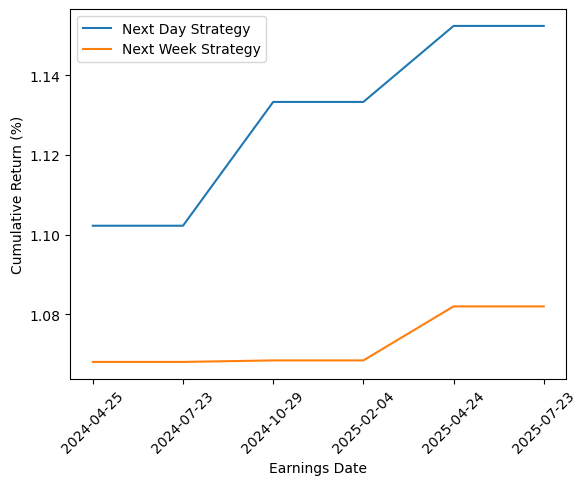

In [26]:
# Plotting results of our sentiment startegy
plt.plot(results['earnings_date'], results['cum_strategy_next_day'], label='Next Day Strategy')
plt.plot(results['earnings_date'], results['cum_strategy_next_week'], label='Next Week Strategy')
plt.xlabel("Earnings Date")  
plt.ylabel("Cumulative Return (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()